In [17]:
import sys

import numpy as np

sys.path.append('..')

from models.psf import KingPSF

In [2]:
k = KingPSF()
psf = k.psf_fermi_r

In [3]:
import numpy as np
from scipy.integrate import quad

def integrand(r, psf):
    return psf(r) * 2 * np.pi * r

In [15]:
norm, err = quad(integrand, 0, 0.1, args=(psf,))

In [7]:
import matplotlib.pyplot as plt

In [20]:
from scipy.optimize import brentq

In [19]:
def containment_radius(psf, containment_fraction=0.68, r_max=0.1):
    # Integrate from 0 to r and subtract containment_fraction
    # to find the zero (i.e., the containment radius).
    def root_func(r):
        result, _ = quad(integrand, 0, r, args=(psf,))
        return result/norm - containment_fraction
    
    r_68 = brentq(root_func, 0, r_max)
    
    return r_68

r_68 = containment_radius(psf)
print(f"68% Containment Radius: {np.rad2deg(r_68)} deg")

68% Containment Radius: 0.22224518888766231 deg


In [23]:
errfunc = lambda r: psf(r) - psf(0)/2
r_FWHM = brentq(errfunc, 0, 0.1)
print(np.rad2deg(r_FWHM))

0.14038875905531056


Text(0, 0.5, 'PSF(r)')

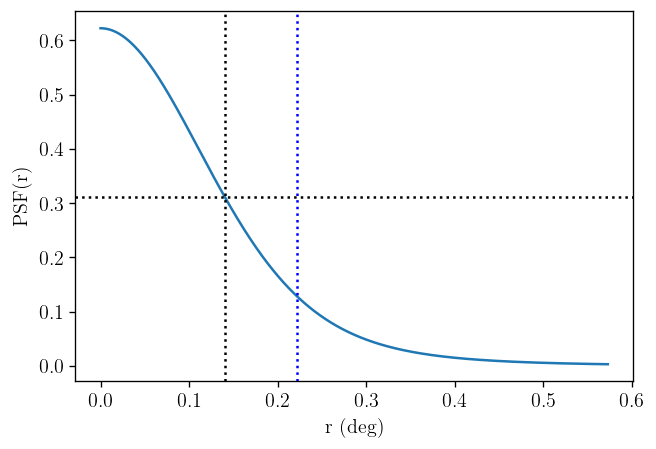

In [30]:
rs = np.linspace(0, 0.01, 1000)
psf_rs = psf(rs)
plt.plot(np.rad2deg(rs), psf_rs)
plt.axhline(psf(0)/2, color='k', ls=':')
plt.axvline(np.rad2deg(r_FWHM), color='k', ls=':')
plt.axvline(np.rad2deg(r_68), color='b', ls=':')
plt.xlabel('r (deg)')
plt.ylabel('PSF(r)')